# Small TTT EDA

One idea is to train a small neural network, then prune. This has yielded a `438` nonzero parameter network from initial testing.

In [1]:
import json
import numpy as np
from data.reps import *

with open('data/fixed_states.json', 'rb') as f:
    states_dict = json.load(f)

X = []
for key, value in states_dict.items():
    
    X.append(trinary_board_rep(key)+value)
X = np.array(X)
np.savetxt('data/fixed_arr.txt', X)

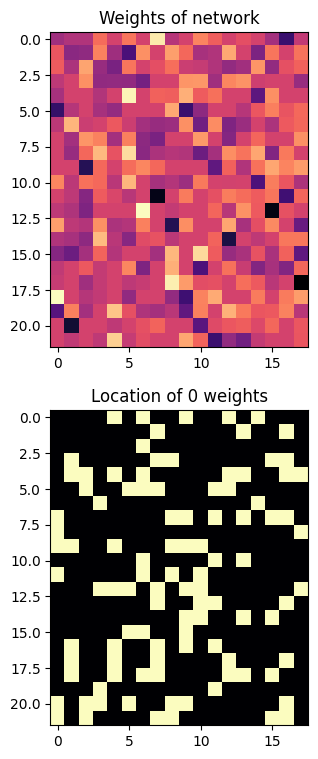

In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from math import floor, ceil

from models.nn import TicTacToeNet
from models.plot_weights import plot_weights

model = TicTacToeNet(hidden_sizes=[22], input_size=9)
# PATH = '/Users/jack/vault/software/smalltictactoe/models/checkpoints/nn_[9, 32, 9]_617_2026-05-03-13:18:18.pth'
# PATH = '/Users/jack/vault/software/smalltictactoe/models/checkpoints/nn_gen48_nonz460_[9, 32, 9].pth'
PATH = '/home/jack/vault/software/smalltictactoe/models/checkpoints/nn_gen20_nonz308_[9, 22, 9].pth'
model.load_state_dict(torch.load(PATH, weights_only=True))

plot_weights(model, ispruned=True)

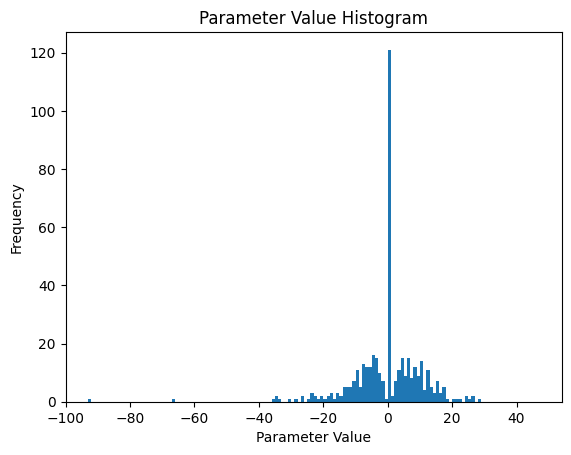

In [6]:
params = []
for param in model.parameters(): params.extend(param.flatten().tolist())
plt.hist(params, bins=np.arange(floor(min(params)), ceil(max(params)), 1))
plt.title('Parameter Value Histogram')
plt.xlabel('Parameter Value')
plt.ylabel('Frequency')
print()

In [ ]:
# plot the parameter, accuracy curve
import torch
import matplotlib.pyplot as plt
from train import param_acc_curve

# NOTE 2_500 epochs seed=2, lr=1e-3 hidden_dim=3, 66 params modeled on fixed gets 48.7% on the full dataset, 24 gets 49.6%, 33 49.7%, 57 gets 50.5%
# hidden dim=4, 85 params 28 gets 53.0, 60 get 55.1%, 

EPOCHS = 2_500
best_seed, best_score = None, 0
for seed in range(100):
    x_data, y_data, z_data, model = param_acc_curve(
        param_min=5,
        param_max=6,
        epochs = EPOCHS,
        seed=seed,
    )
    if z_data[0] > best_score:
        best_seed = seed
        best_score = z_data[0]
        print(f'Best seed so far: {best_seed}, at {best_score*100:.4f}%')
    # print(f'Seed: {seed}')
    # for num in y_data: print(f'{num:.3f}', end=', ')
    # print()
    # for num in z_data: print(f'{num:.3f}', end=', ')
    # plt.plot(x_data, y_data, label=f'{seed} Fixed %')
    # plt.plot(x_data, z_data, label=f'{seed} Full %')

num_params = sum(p.numel() for p in model.parameters())

checkpoint_path = f'models/checkpoints/nn_seed_{best_seed}_{best_score*100:.4f}_{model.hidden_sizes}_{num_params}_.pth'
model.zero_grad() # zero grads for file size
torch.save(model.state_dict(), checkpoint_path)
print(f'Model saved at: {checkpoint_path}')

# fig = plt.figure(figsize=(12,12))
# plt.title(f'TTTNN Pareto, Epochs: {EPOCHS}')
# plt.xlabel('Number of parameters')
# plt.ylabel('Accuracy on dataset')
# plt.legend()

Seed: 0, Hidden: 5: 100%|██████████| 1/1 [00:14<00:00, 14.90s/it]


Best seed so far: 0, at 49.8009%


Seed: 1, Hidden: 5: 100%|██████████| 1/1 [00:14<00:00, 14.99s/it]


Best seed so far: 1, at 51.7257%


Seed: 2, Hidden: 5: 100%|██████████| 1/1 [00:14<00:00, 14.98s/it]


...

Best seed so far: 9, at 57.6549%


Seed: 34, Hidden: 5: 100%|██████████| 1/1 [00:14<00:00, 14.22s/it]


Best seed so far: 34, at 59.8894%


Seed: 99, Hidden: 5: 100%|██████████| 1/1 [00:13<00:00, 13.92s/it]


NameError: name 'torch' is not defined

In [10]:
import matplotlib.pyplot as plt
from train import param_acc_curve

# EPOCHS = 4_500
EPOCHS = 10_000 # 52.1681
# EPOCHS = 20_000 # 52.1681
seed = 22
x_data, y_data, z_data, model = param_acc_curve(
    param_min=3,
    param_max=4,
    epochs=EPOCHS,
    seed=seed,
)
percent_acc = z_data[0]*100
num_params = sum(p.numel() for p in model.parameters())
print(f'full acc: {percent_acc:.4f}')

checkpoint_path = f'models/checkpoints/nn_seed_{seed}_{percent_acc:.4f}_{model.hidden_sizes}_{num_params}_.pth'
model.zero_grad() # zero grads for file size
torch.save(model.state_dict(), checkpoint_path)
print(f'Model saved at: {checkpoint_path}')


Hidden: 3 done: 100%|██████████| 1/1 [00:56<00:00, 56.65s/it]

full acc: 52.1681
Model saved at: models/checkpoints/nn_seed_22_52.1681_[9, 3, 9]_66_.pth


In [13]:
import json
from data.reps import *
from data.game import generate_states_from_root_board

model = TicTacToeNet(hidden_sizes=[3], input_size=9)
PATH = 'models/checkpoints/nn_seed_22_52.1681_[9, 3, 9]_66_.pth'
model.load_state_dict(torch.load(PATH, weights_only=True))

board_rep_func = trinary_board_rep

all_states = generate_states_from_root_board([' '] * 9, 'X')

all_dataset = []
for board_str, moves in all_states.items():
    binary_board = board_rep_func(board_str=board_str)
    all_dataset.append(binary_board)
all_dataset = np.array(all_dataset, dtype=np.int32)
all_dataset = torch.from_numpy(all_dataset).float()

correct_states, incorrect_states, router_states = {}, {}, {}

predictions = torch.argmax(model(all_dataset), dim=1)
for idx, (board_str, moves) in enumerate(all_states.items()):
    if predictions[idx] in moves:
        correct_states[board_str] = moves
        router_states[board_str] = [0]
    else:
        incorrect_states[board_str] = moves
        router_states[board_str] = [1]


with open(f'data/residual_{len(incorrect_states)}_dataset.json', 'w') as fp:
    json.dump(incorrect_states, fp)
with open(f'data/router_dataset.json', 'w') as fp:
    json.dump(router_states, fp)

In [ ]:
zerocount, total = 0, 0
for param in model.parameters(): 
    tens = param.flatten().tolist()
    for thing in tens:
        total += 1
        if thing == 0:
            zerocount += 1

print(f'Params: {total}, Zero: {zerocount}, Model sparcity: {zerocount/total*100:.3f}%')

Params: 617, Non-zero: 157, Model sparcity: 25.446%


In [13]:
model2 = TicTacToeNet(hidden_sizes=[4], input_size=9)
num_params = sum(p.numel() for p in model2.parameters())
print(f'Num parameters: {num_params}')

Num parameters: 85


In [18]:
import json
with open('data/fixed_states.json', 'rb') as f:
    states_dict = json.load(f)

In [19]:
hist = {i:0 for i in range(9)}
for key, value in states_dict.items():
    hist[value[0]] += 1
for key, value in hist.items(): print(f'hist {key}: {value}')

hist 0: 318
hist 1: 159
hist 2: 318
hist 3: 159
hist 4: 498
hist 5: 159
hist 6: 318
hist 7: 159
hist 8: 318


In [2]:
import numpy as np
data = np.loadtxt('data/fixed_arr.txt')
X, Y = data[:, :9], data[:, 9:]
print(f'X.shape: {X.shape} Y.shape: {Y.shape}')

X.shape: (2406, 9) Y.shape: (2406, 1)


In [8]:
sym_map = {
    0:0,
    1:1,
    2:0,
    3:1,
    4:2,
    5:1,
    6:0,
    7:1,
    8:0,
}

mapped_Y = []
for elem in Y:
    mapped_Y.append([sym_map[elem[0]]])
mapped_Y = np.array(mapped_Y)

/Users/jack/vault/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(2406, 2) (2406, 2)


Text(0.5, 1.0, 'UMAP for fixed points')

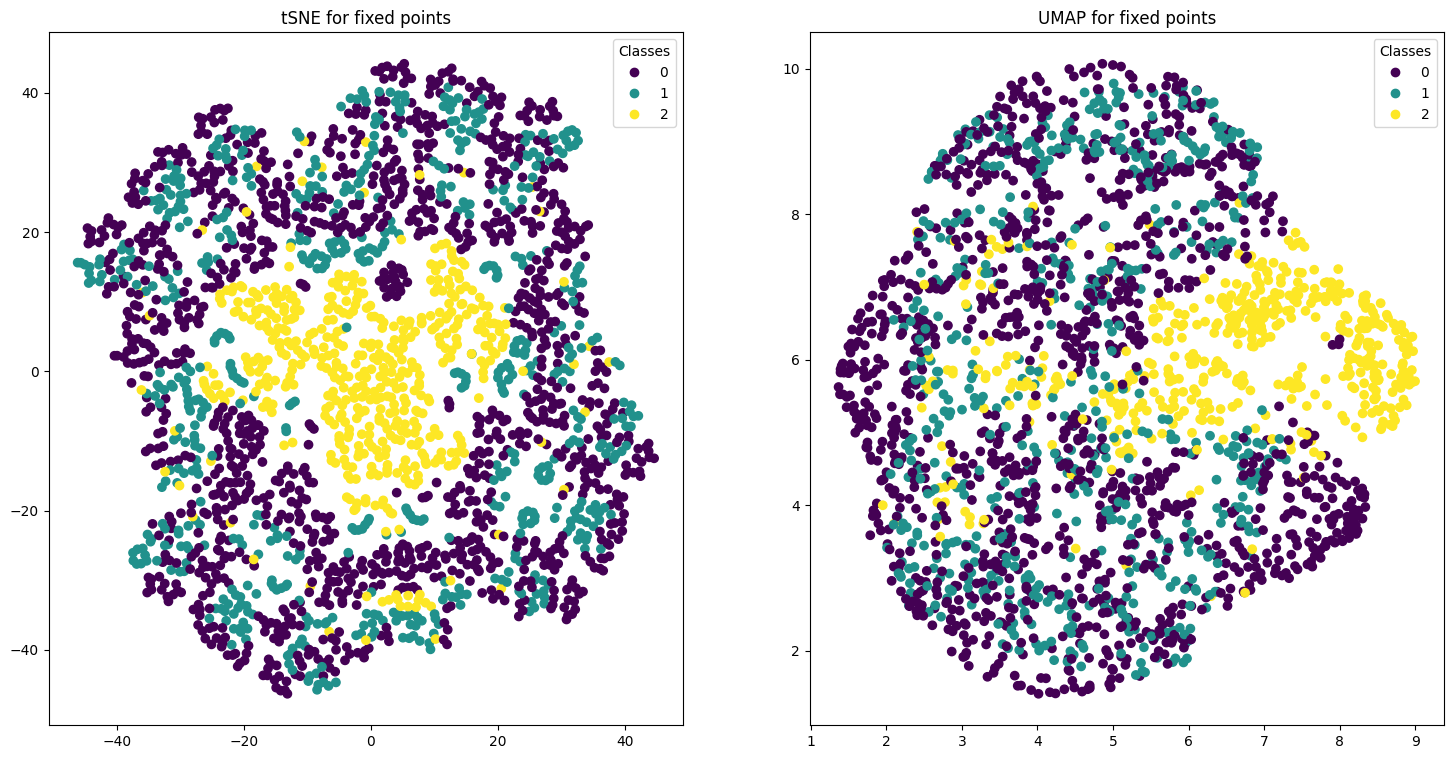

In [9]:
import sklearn
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import umap

tsne = TSNE()

tsne_embeds = tsne.fit_transform(X)
umap_embeds = umap.UMAP().fit_transform(X)
print(tsne_embeds.shape, umap_embeds.shape)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(18,9))
scatter = ax1.scatter(tsne_embeds[:, 0], tsne_embeds[:, 1], c=mapped_Y, cmap='viridis')
legend = ax1.legend(*scatter.legend_elements(), title="Classes")
ax1.set_title(f'tSNE for fixed points')
scatter = ax2.scatter(umap_embeds[:, 0], umap_embeds[:, 1], c=mapped_Y, cmap='viridis')
legend = ax2.legend(*scatter.legend_elements(), title="Classes")
ax2.set_title(f'UMAP for fixed points')


In [10]:
### EDA for the state space of ttt
import json
from data.reps import *
with open('data/all_states.json', 'rb') as f:
    all_states = json.load(f)

In [14]:
hist = [0,0,0,0]
for state, moves in all_states.items():
    if 4 in moves: hist[0] += 1
    elif (0 in moves or 2 in moves or 6 in moves or 8 in moves) and (1 in moves or 3 in moves or 5 in moves or 7 in moves): hist[3] += 1
    elif (0 in moves or 2 in moves or 6 in moves or 8 in moves): hist[1] += 1   
    elif (1 in moves or 3 in moves or 5 in moves or 7 in moves): hist[2] += 1   

hist_str = f'''
center moves: {hist[0]}
corner: {hist[1]}
edge: {hist[2]}
corner and edge: {hist[3]}
'''
print(hist_str)


center moves: 1323
corner: 1521
edge: 734
corner and edge: 942



In [15]:
# how many boards are distinct under rotations and reflections
def get_syms(r):
    syms = [ # using notation from "F" diagram at: https://en.wikipedia.org/wiki/Dihedral_group_of_order_8
        [# e
            [r[0][0],r[0][1], r[0][2]],
            [r[1][0],r[1][1], r[1][2]],
            [r[2][0],r[2][1], r[2][2]],
        ],
        [ # a
            [r[2][0],r[1][0], r[0][0]],
            [r[2][1],r[1][1], r[0][1]],
            [r[2][2],r[1][2], r[0][2]],
        ],
        [ # a2
            [r[2][2],r[2][1], r[2][0]],
            [r[1][2],r[1][1], r[1][0]],
            [r[0][2],r[0][1], r[0][0]],
        ],
        [ # a3
            [r[0][2],r[1][2], r[2][2]],
            [r[0][1],r[1][1], r[2][1]],
            [r[0][0],r[1][0], r[2][0]],
        ],
        [ # b
            [r[0][2],r[0][1], r[0][0]],
            [r[1][2],r[1][1], r[1][0]],
            [r[2][2],r[2][1], r[2][0]],
        ],
        [ # ab
            [r[0][0],r[1][0], r[2][0]],
            [r[0][1],r[1][1], r[2][1]],
            [r[0][2],r[1][2], r[2][2]],
        ],
        [ # a2b
            [r[2][0],r[2][1], r[2][2]],
            [r[1][0],r[1][1], r[1][2]],
            [r[0][0],r[0][1], r[0][2]],
        ],
        [ # a3b
            [r[2][2],r[1][2], r[0][2]],
            [r[2][1],r[1][1], r[0][1]],
            [r[2][0],r[1][0], r[0][0]],
        ],

    ]
    return syms

symmetric_states = []
for key, _ in all_states.items():
    rep = trinary_board_rep(key)
    rep = [rep[0:3], rep[3:6], rep[6:9]]
    syms = get_syms(rep)

    is_new = True
    for thing in symmetric_states:
        if rep in thing:
            is_new = False
    if is_new:
        symmetric_states.append(syms)
print(len(symmetric_states))
    

627


In [42]:
def warp_board(board): return [board[0][0], board[0][1], board[0][2],board[1][0], board[1][1], board[1][2],board[2][0], board[2][1], board[2][2]]
my_boards = [warp_board(thing[0]) for thing in symmetric_states]
my_boards

[[0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, -1, 0, 0, 0, 0, 0, 0, 0],
 [1, -1, 1, 0, 0, 0, 0, 0, 0],
 [1, -1, 1, -1, 0, 0, 0, 0, 0],
 [1, -1, 1, -1, 1, 0, 0, 0, 0],
 [1, -1, 1, -1, 1, -1, 0, 0, 0],
 [1, -1, 1, -1, 1, -1, 0, 1, 0],
 [1, -1, 1, -1, 1, -1, -1, 1, 0],
 [1, -1, 1, -1, 1, 0, -1, 0, 0],
 [1, -1, 1, -1, 1, 1, -1, 0, 0],
 [1, -1, 1, -1, 1, 1, -1, -1, 0],
 [1, -1, 1, -1, 1, 1, -1, 0, -1],
 [1, -1, 1, -1, 1, 0, -1, 1, 0],
 [1, -1, 1, -1, 1, 0, -1, 1, -1],
 [1, -1, 1, -1, 1, 0, 0, -1, 0],
 [1, -1, 1, -1, 1, 1, 0, -1, 0],
 [1, -1, 1, -1, 1, 1, 0, -1, -1],
 [1, -1, 1, -1, 1, 0, 0, 0, -1],
 [1, -1, 1, -1, 1, 1, 0, 0, -1],
 [1, -1, 1, -1, 1, 0, 0, 1, -1],
 [1, -1, 1, -1, 0, 1, 0, 0, 0],
 [1, -1, 1, -1, -1, 1, 0, 0, 0],
 [1, -1, 1, -1, -1, 1, 1, 0, 0],
 [1, -1, 1, -1, -1, 1, 1, 0, -1],
 [1, -1, 1, -1, -1, 1, 0, 1, 0],
 [1, -1, 1, -1, -1, 1, -1, 1, 0],
 [1, -1, 1, -1, -1, 1, 0, 1, -1],
 [1, -1, 1, -1, 0, 1, -1, 0, 0],
 [1, -1, 1, -1, 0, 1, -1, 1, 0],
 [1, -1, 1, -1,

In [44]:
import itertools
import numpy as np
from scipy.optimize import milp, LinearConstraint, Bounds

# --- 1. Symmetries of the 3x3 Board ---
# Indices for the 9 squares:
# 0 1 2
# 3 4 5
# 6 7 8
SYMMETRIES = [
    (0,1,2, 3,4,5, 6,7,8), # Identity
    (2,5,8, 1,4,7, 0,3,6), # Rotate 90
    (8,7,6, 5,4,3, 2,1,0), # Rotate 180
    (6,3,0, 7,4,1, 8,5,2), # Rotate 270
    (2,1,0, 5,4,3, 8,7,6), # Flip Vertical (Left/Right)
    (6,7,8, 3,4,5, 0,1,2), # Flip Horizontal (Top/Bottom)
    (0,3,6, 1,4,7, 2,5,8), # Flip Diagonal 1
    (8,5,2, 7,4,1, 6,3,0)  # Flip Diagonal 2
]

def apply_sym(board, sym):
    """Permutes the board array according to a symmetry map."""
    return tuple(board[i] for i in sym)

# --- 2. Numeric Reynolds Evaluator ---
def evaluate_monomial(board, powers):
    """Evaluates a single monomial (represented by a tuple of powers) on a board."""
    val = 1
    for b_val, p in zip(board, powers):
        if p == 1:
            val *= b_val
        elif p == 2:
            val *= (b_val * b_val)
    return val

def evaluate_reynolds(board, powers):
    """Applies the Reynolds operator by summing the monomial over all symmetries."""
    return sum(evaluate_monomial(apply_sym(board, s), powers) for s in SYMMETRIES)

# --- 3. The Core Algorithm ---
def run_phase_1(canonical_boards, max_degree=3):
    """
    canonical_boards: A list of tuples, where each tuple is length 9 containing -1, 0, 1.
                      Only pass one board per symmetric orbit (no duplicates).
    """
    print(f"Loaded {len(canonical_boards)} canonical boards.")
    
    # Step 1: Generate Candidate Monomials (powers 0, 1, 2 only due to x^3 = x)
    valid_powers = [0, 1, 2]
    # Exclude the empty monomial (all zeros) by starting sum > 0
    all_monomials = [
        p for p in itertools.product(valid_powers, repeat=9) 
        if 0 < sum(p) <= max_degree
    ]
    print(f"Generated {len(all_monomials)} candidate monomials (max degree {max_degree}).")
    
    # Step 2: Build Evaluation Matrix
    # Rows correspond to boards, columns correspond to polynomials
    eval_matrix = np.zeros((len(canonical_boards), len(all_monomials)), dtype=int)
    for i, board in enumerate(canonical_boards):
        for j, powers in enumerate(all_monomials):
            eval_matrix[i, j] = evaluate_reynolds(board, powers)
            
    # Step 3: Filter out redundant polynomials
    # The Reynolds operator turns many distinct monomials into the exact same invariant sum.
    # We find unique columns to drastically reduce the matrix size for the ILP.
    unique_evals, unique_indices = np.unique(eval_matrix, axis=1, return_index=True)
    unique_monomials = [all_monomials[idx] for idx in unique_indices]
    print(f"Filtered down to {len(unique_monomials)} unique invariant polynomials.")
    
    # Step 4: Build Separating Matrix for the Set Cover problem
    num_boards = len(canonical_boards)
    pair_count = (num_boards * (num_boards - 1)) // 2
    
    print(f"Building separation matrix for {pair_count} distinct board pairs...")
    separation_matrix = np.zeros((pair_count, len(unique_monomials)), dtype=int)
    
    row_idx = 0
    for i in range(num_boards):
        for j in range(i + 1, num_boards):
            # Place a 1 if the polynomial gives a different result for board i and j
            separation_matrix[row_idx, :] = (unique_evals[i] != unique_evals[j]).astype(int)
            row_idx += 1
            
    # Verify that the chosen max_degree successfully separates everything
    unseparated_pairs = np.where(separation_matrix.sum(axis=1) == 0)[0]
    if len(unseparated_pairs) > 0:
        raise ValueError(
            f"{len(unseparated_pairs)} pairs cannot be distinguished. "
            "Increase max_degree to generate more complex invariants."
        )
        
    # Step 5: Solve the Set Cover via ILP
    print("Solving Integer Linear Program (this may take a moment)...")
    
    # We want to select polynomials (cost of 1 each) to minimize total selected
    c = np.ones(len(unique_monomials)) 
    
    # Constraint: Every pair (row) must be covered by at least 1 selected polynomial
    constraints = LinearConstraint(separation_matrix, lb=1, ub=np.inf)
    
    # All variables must be 0 or 1 (binary decision to include the polynomial or not)
    integrality = np.ones_like(c) 
    bounds = Bounds(0, 1)
    
    res = milp(c=c, constraints=constraints, integrality=integrality, bounds=bounds)
    
    if not res.success:
        print("ILP Solver failed:", res.message)
        return None
        
    # Step 6: Format the Results
    selected_indices = np.where(res.x > 0.5)[0]
    print(f"\nSUCCESS! Found a minimal set of {len(selected_indices)} basic invariants.")
    
    final_polynomials = []
    for idx in selected_indices:
        powers = unique_monomials[idx]
        final_polynomials.append(powers)
        
        # Translate the powers tuple back into readable algebra
        terms = []
        for v_idx, p in enumerate(powers):
            if p == 0: continue
            var_name = f"b{v_idx}"
            terms.append(var_name if p == 1 else f"{var_name}^2")
            
        print(f" - Include the Reynolds operator applied to: {' * '.join(terms)}")
        
    return final_polynomials

final_polynomials = run_phase_1(my_boards, max_degree=3)
final_polynomials

Loaded 627 canonical boards.
Generated 210 candidate monomials (max degree 3).
Filtered down to 42 unique invariant polynomials.
Building separation matrix for 196251 distinct board pairs...
Solving Integer Linear Program (this may take a moment)...

SUCCESS! Found a minimal set of 9 basic invariants.
 - Include the Reynolds operator applied to: b7 * b8
 - Include the Reynolds operator applied to: b2 * b6
 - Include the Reynolds operator applied to: b2 * b3 * b8
 - Include the Reynolds operator applied to: b4
 - Include the Reynolds operator applied to: b5 * b7
 - Include the Reynolds operator applied to: b5 * b7 * b8
 - Include the Reynolds operator applied to: b6 * b8
 - Include the Reynolds operator applied to: b7^2
 - Include the Reynolds operator applied to: b8


[(0, 0, 0, 0, 0, 0, 0, 1, 1),
 (0, 0, 1, 0, 0, 0, 1, 0, 0),
 (0, 0, 1, 1, 0, 0, 0, 0, 1),
 (0, 0, 0, 0, 1, 0, 0, 0, 0),
 (0, 0, 0, 0, 0, 1, 0, 1, 0),
 (0, 0, 0, 0, 0, 1, 0, 1, 1),
 (0, 0, 0, 0, 0, 0, 1, 0, 1),
 (0, 0, 0, 0, 0, 0, 0, 2, 0),
 (0, 0, 0, 0, 0, 0, 0, 0, 1)]

In [ ]:
'''
b0 b1 b2
b3 b4 b5
b6 b7 b8

b4
b2 * b6
b5 * b7
b8
b7^2
b6 * b8
b2 * b3 * b8
b5 * b7 * b8
b7 * b8
'''
## check if rep works
def sym_rep_fn(board): 
    '''
    c1 e1 c2
    e2 c e3
    c3 e4 c4
    '''
    row1, row2, row3 = board
    c1, e1, c2 = row1
    e2, c,  e3 = row2
    c3, e4, c4 = row3
    return (
        c,
        c1+c2+c3+c4,
        c2*c3 + c1*c4,
        e1*e2 + e1*e3 + e2*e4 + e3*e4,
        e1**2 + e2**2 + e3**2 + e4**2,
        c1*c2 + c1*c3 + c2*c4 + c3*c4,
        c1*c2*e4 + c2*c4*e2 + c3*c4*e1 + c1*c3*e3,
        c1*e1*e2 + c2*e1*e3 + c4*e3*e4 + c3*e2*e4,
        c1*e1 + c1*e2 + c2*e1 + c2*e3 + c4*e3 + c4*e4 + c3*e2 + c3*e4,
    )

## do all reps in the same symmetric group have the same 
reps_dict = {}
for rep_num, reps in enumerate(symmetric_states):
    reps_per_sym = set()
    for board in reps:
        board_rep = sym_rep_fn(board)
        reps_per_sym.add(board_rep)
    if len(reps_per_sym) != 1:
        print(f'Not all board positions in a symmetric group have the same representation! {reps_per_sym}')
        break
    else:
        if board_rep in reps_dict:
            error_str = f'''Collision at rep {rep_num}. The same representation has been given to distinct board symmetry classes!
Board rep: {board_rep}
Reps:
{np.array(reps[0])}
Collides with:
{np.array(reps_dict[board_rep][0])}
            '''
            print(error_str)
            break
        else:
            reps_dict[board_rep] = reps



In [ ]:
# how many board only have one move?
full_tot = 0
for key, _ in all_states.items():
    tot = 0
    for char in key:
        if char == ' ':
            tot += 1
    if tot == 1:
        full_tot += 1
full_tot

222

In [ ]:
# how many boards is playing in the center (when it is available) the best move
tot_plays = 0
tot = 0
for key, value in all_states.items():
    if key[4] == ' ':
        tot += 1
        if 4 in value:
            tot_plays += 1

print(f'{tot_plays}/{tot} = {tot_plays/tot}')

1323/1883 = 0.7026022304832714


Another challenge of the tictactoe parameter golf challenge is that the dataset is not fixed. More than half of the datapoints in the dataset admit more than one optimal solution. Sometimes it is useful to focus on the points in which there is a single answer, which we refer to as the `fixed_states`.

There is a lot of symmetry in the tictactoe dataset. Most board positions are one of 8 symmetric boards, with only 627 unique boards to learn up to symmetry. This is almost (as expected) an 8-fold reduction.

An initial idea was to find a function that maps each board to a rotation and reflection invariant representation, then feeding the representation to a smaller network. This reduces the data required for the network to learn, allowing for smaller sizes. However, the problem is that although the boards are D8 symmetric, the outputs are not. This could, for example, be used to make a small network that outputs whether the optimal answer is a corner, edge, or center, but clearly this is not sufficient for the challenge. There needs to be some way that the symmetry can be exploited while still preserving the 


